#Load the data

In [69]:
#Autism Disease Prediction
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.mlab as mlab
%matplotlib inline

data = pd.read_csv("autismData.csv")
print(data.shape)
data.head()


(704, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jaundice,autism,country_of_res,used_app_before,result,age_desc,relation,Class_ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO


# Data Pre-processing

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   A1_Score         704 non-null    int64 
 1   A2_Score         704 non-null    int64 
 2   A3_Score         704 non-null    int64 
 3   A4_Score         704 non-null    int64 
 4   A5_Score         704 non-null    int64 
 5   A6_Score         704 non-null    int64 
 6   A7_Score         704 non-null    int64 
 7   A8_Score         704 non-null    int64 
 8   A9_Score         704 non-null    int64 
 9   A10_Score        704 non-null    int64 
 10  age              704 non-null    object
 11  gender           704 non-null    object
 12  ethnicity        704 non-null    object
 13  jaundice         704 non-null    object
 14  autism           704 non-null    object
 15  country_of_res   704 non-null    object
 16  used_app_before  704 non-null    object
 17  result           704 non-null    in

In [71]:
data.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,result
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000
mean,0.721591,0.453125,0.457386,0.495739,0.498580,0.284091,0.417614,0.649148,0.323864,0.573864,4.875000
std,0.448535,0.498152,0.498535,0.500337,0.500353,0.451301,0.493516,0.477576,0.468281,0.494866,2.501493
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,4.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000


In [72]:
data.dtypes

A1_Score            int64
A2_Score            int64
A3_Score            int64
A4_Score            int64
A5_Score            int64
A6_Score            int64
A7_Score            int64
A8_Score            int64
A9_Score            int64
A10_Score           int64
age                object
gender             object
ethnicity          object
jaundice           object
autism             object
country_of_res     object
used_app_before    object
result              int64
age_desc           object
relation           object
Class_ASD          object
dtype: object

# Clean the data

In [73]:
# Checking for any null values
data.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jaundice           0
autism             0
country_of_res     0
used_app_before    0
result             0
age_desc           0
relation           0
Class_ASD          0
dtype: int64

# Exploratory Data Analysis

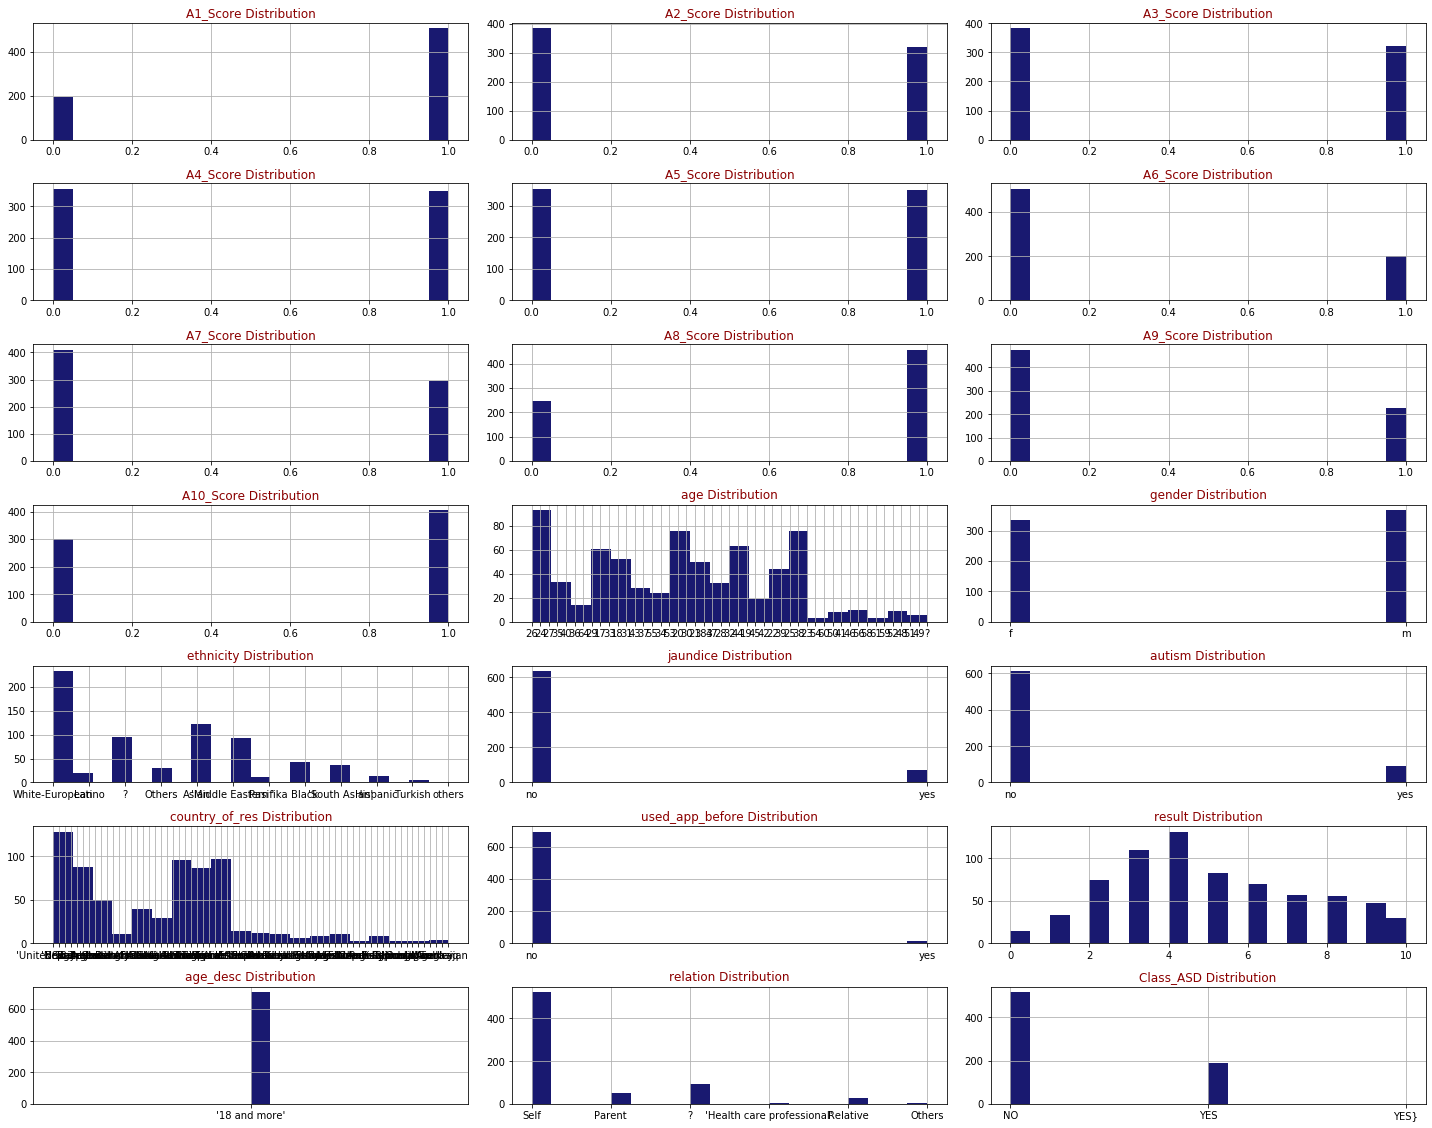

In [74]:
# Check Data distribution
def draw_histograms(dataframe,features,rows,cols):
    fig=plt.figure(figsize=(20,20))
    for i, feature in enumerate(features):
        ax=fig.add_subplot(rows,cols,i+1)
        dataframe[feature].hist(bins=20,ax=ax,facecolor='midnightblue')
        ax.set_title(feature+" Distribution",color='DarkRed')
    fig.tight_layout()
    plt.show()
draw_histograms(data,data.columns,9,3)


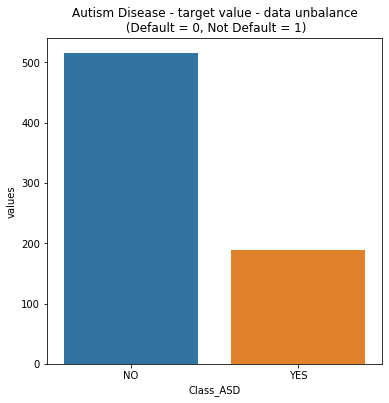

In [75]:
#check data  is balanced or not
## Checking for data unbalance
data['Class_ASD']=data['Class_ASD'].replace("YES}","YES")
temp = data["Class_ASD"].value_counts()
df = pd.DataFrame({'Class_ASD': temp.index,'values': temp.values})
plt.figure(figsize = (6,6))
plt.title('Autism Disease - target value - data unbalance\n (Default = 0, Not Default = 1)')
sns.set_color_codes("pastel")
sns.barplot(x = 'Class_ASD', y="values", data=df)
locs, labels = plt.xticks()
plt.show()



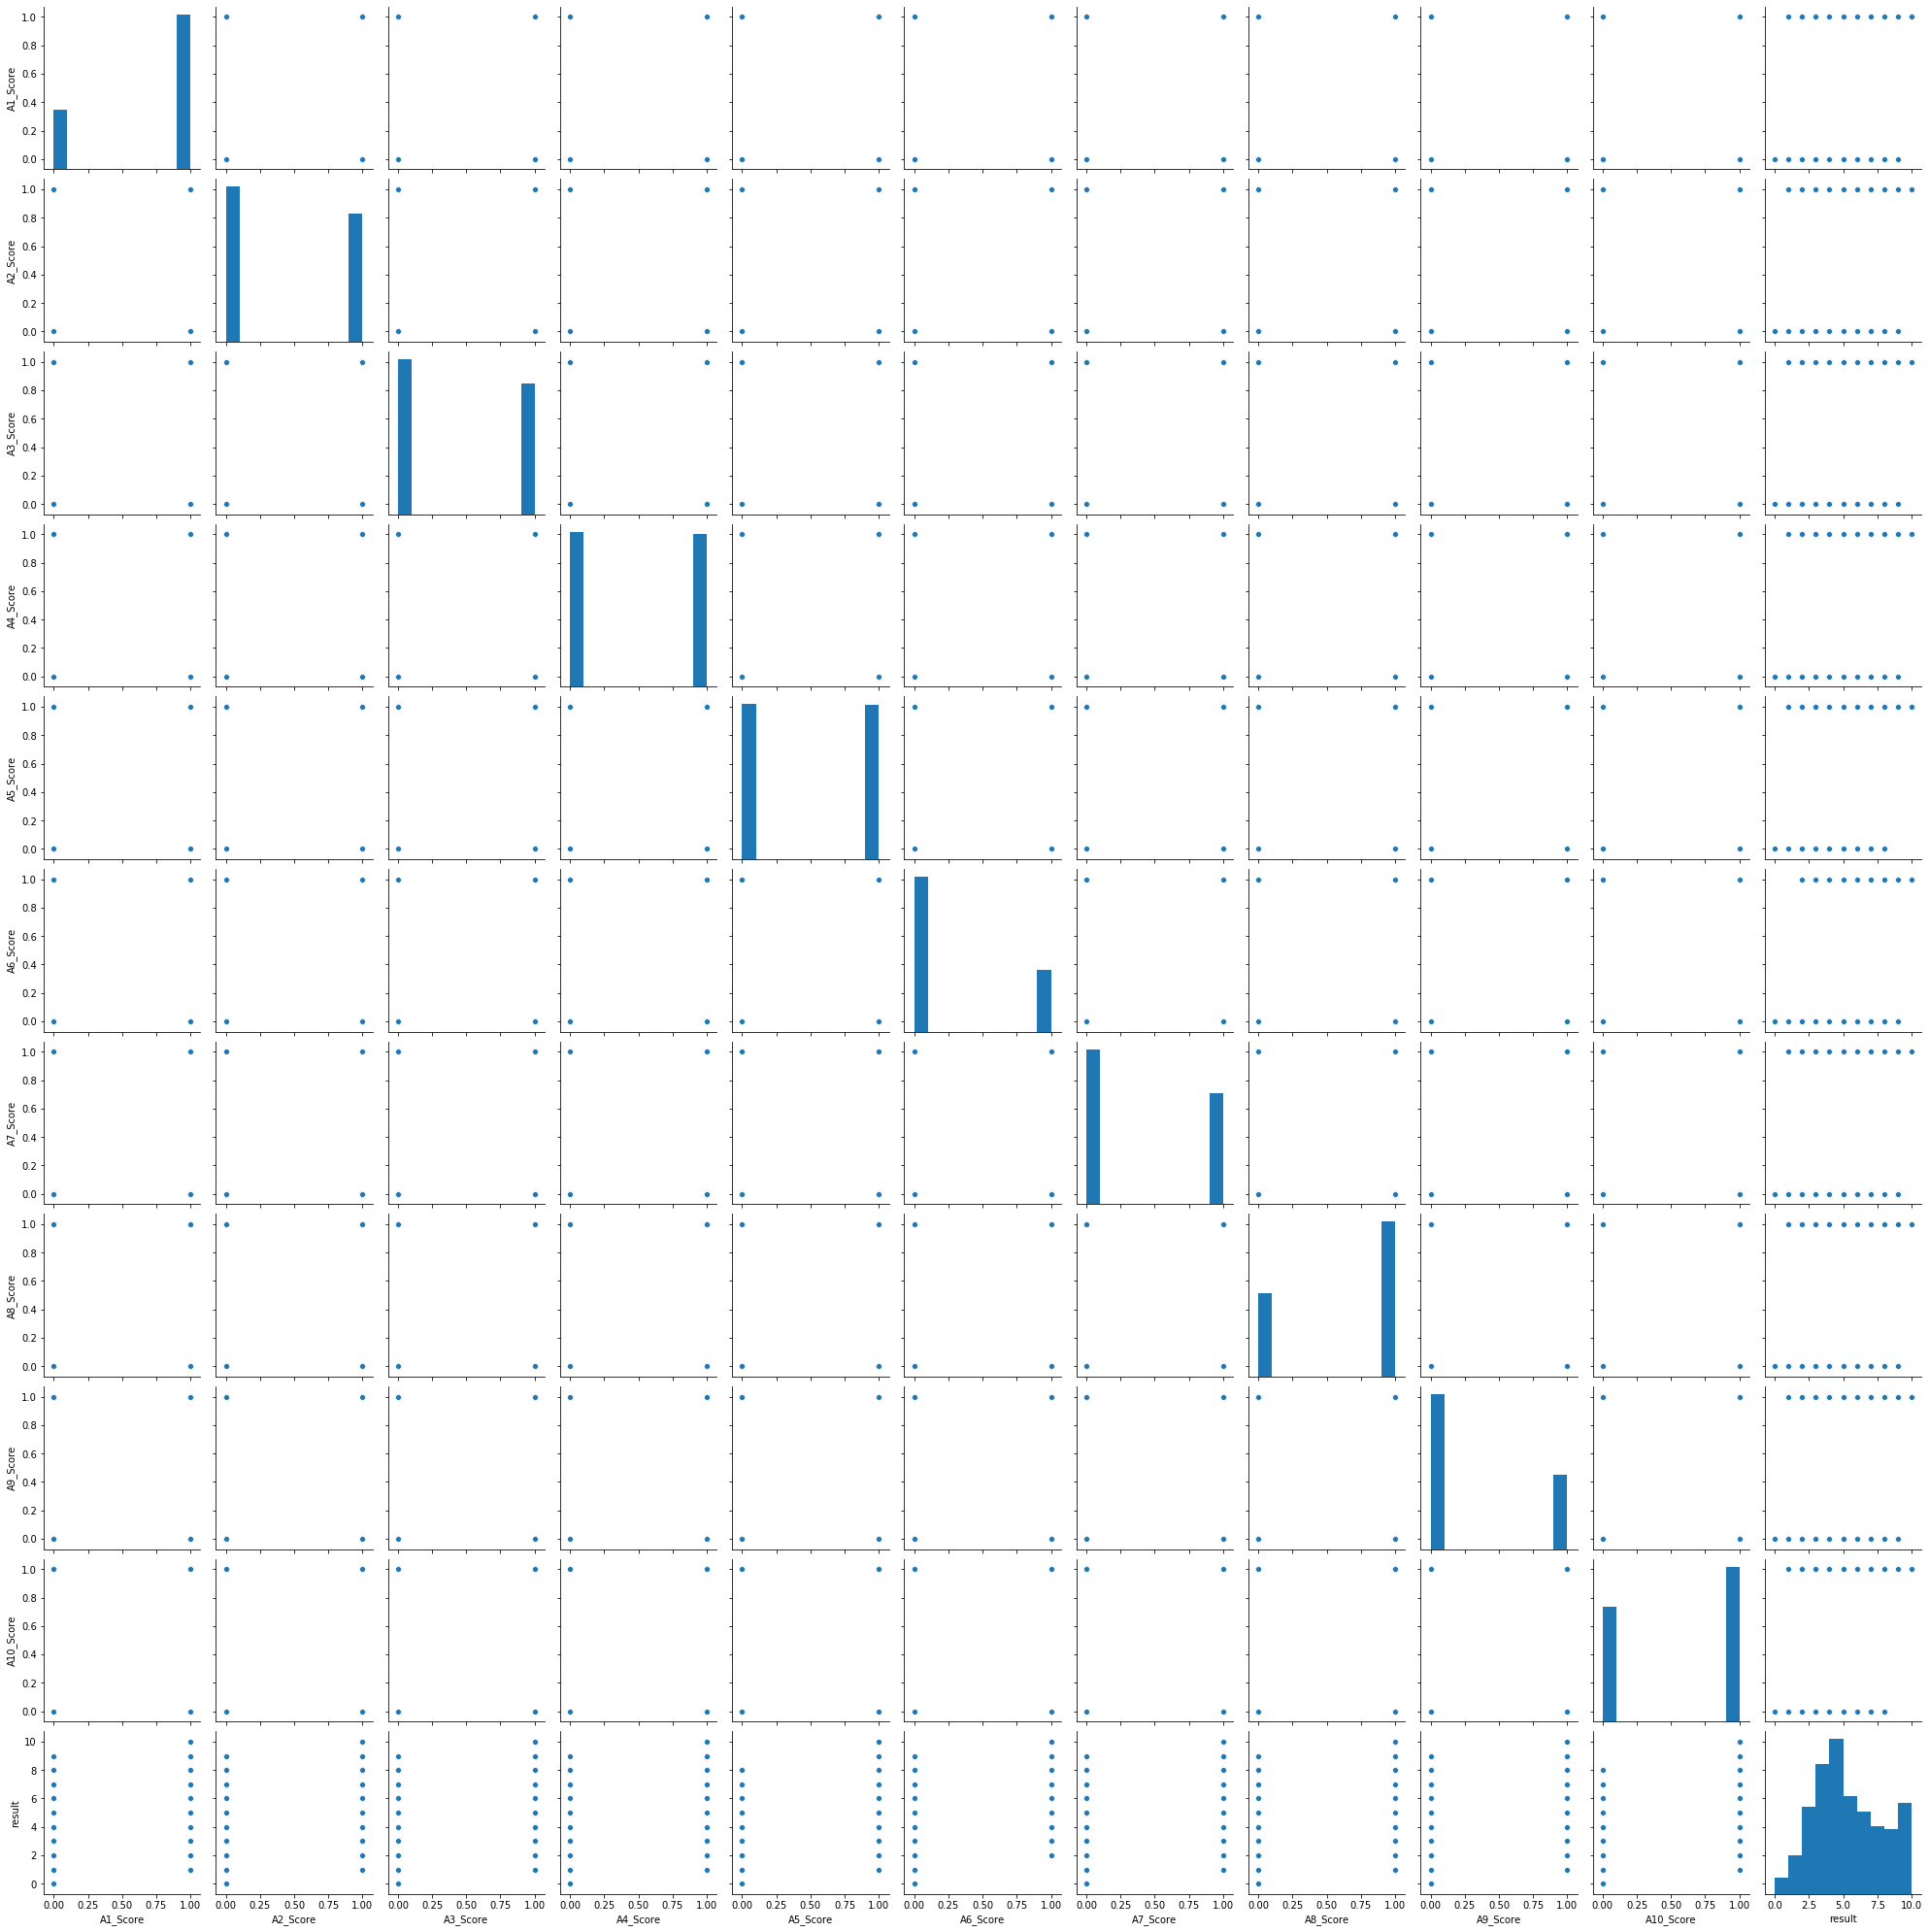

In [76]:

sns.pairplot(data=data)

In [77]:
for col in data:
    print("colname : "+col )
    print(data[col].unique())

colname : A1_Score
[1 0]
colname : A2_Score
[1 0]
colname : A3_Score
[1 0]
colname : A4_Score
[1 0]
colname : A5_Score
[0 1]
colname : A6_Score
[0 1]
colname : A7_Score
[1 0]
colname : A8_Score
[1 0]
colname : A9_Score
[0 1]
colname : A10_Score
[0 1]
colname : age
['26' '24' '27' '35' '40' '36' '64' '29' '17' '33' '18' '31' '43' '37'
 '55' '34' '53' '20' '30' '21' '383' '47' '28' '32' '44' '19' '45' '42'
 '22' '39' '25' '38' '23' '54' '60' '50' '41' '46' '56' '58' '61' '59'
 '52' '48' '51' '49' '?']
colname : gender
['f' 'm']
colname : ethnicity
['White-European' 'Latino' '?' 'Others' 'Asian' "'Middle Eastern '"
 'Pasifika' 'Black' "'South Asian'" 'Hispanic' 'Turkish' 'others']
colname : jaundice
['no' 'yes']
colname : autism
['no' 'yes']
colname : country_of_res
["'United States'" 'Brazil' 'Spain' 'Egypt' "'New Zealand'" 'Bahamas'
 'Austria' 'Argentina' 'Jordan' 'Lebanon' "'South Africa'" 'Italy'
 'Bangladesh' 'Chile' 'France' 'China' 'Australia' 'Canada'
 "'Saudi Arabia'" 'Netherland

In [78]:
# Treat incorrect data
print("Count of age values with ? :: ",
      data[data['age'] == '?']['age'].count())
data['age1'] = data[data['age'] != '?']['age'].astype(int)

print('age mean : ',str(int(data['age1'].mean())))
data['age'] = data['age'].str.replace('?',str(int(data['age1'].mean())))

print("Count of age values with ? :: ",
      data[data['age'] == '?']['age'].count())

data.drop(['age1'], axis = 1,inplace = True)

data['age'].unique()


Count of age values with ? ::  2
age mean :  29
Count of age values with ? ::  0


array(['26', '24', '27', '35', '40', '36', '64', '29', '17', '33', '18',
       '31', '43', '37', '55', '34', '53', '20', '30', '21', '383', '47',
       '28', '32', '44', '19', '45', '42', '22', '39', '25', '38', '23',
       '54', '60', '50', '41', '46', '56', '58', '61', '59', '52', '48',
       '51', '49'], dtype=object)

In [79]:
# Treat incorrect data for relation attribute
print("Count of relation values with ? :: ",
      data[data['relation'] == '?']['relation'].count())
print('data[relation].mode() >> ',data['relation'].mode()[0])
data['relation'] = data['relation'].str.replace('?',data['relation'].mode()[0])
data['relation'].unique()


Count of relation values with ? ::  95
data[relation].mode() >>  Self


array(['Self', 'Parent', "'Health care professional'", 'Relative',
       'Others'], dtype=object)

In [80]:
# Treat incorrect data for ethinicity attribute
print("Count of ethnicity values with ? :: ",
      data[data['ethnicity'] == '?']['ethnicity'].count())
print("unique ethinicity before >> ",data['ethnicity'].unique())

data['ethnicity'] = data['ethnicity'].str.replace('?',data['ethnicity'].mode()[0])
print("unique ethinicity after >> ",data['ethnicity'].unique())

Count of ethnicity values with ? ::  95
unique ethinicity before >>  ['White-European' 'Latino' '?' 'Others' 'Asian' "'Middle Eastern '"
 'Pasifika' 'Black' "'South Asian'" 'Hispanic' 'Turkish' 'others']
unique ethinicity after >>  ['White-European' 'Latino' 'Others' 'Asian' "'Middle Eastern '" 'Pasifika'
 'Black' "'South Asian'" 'Hispanic' 'Turkish' 'others']


In [81]:
#find outliers
X=data.drop(['Class_ASD'],axis=1)
y=data.Class_ASD

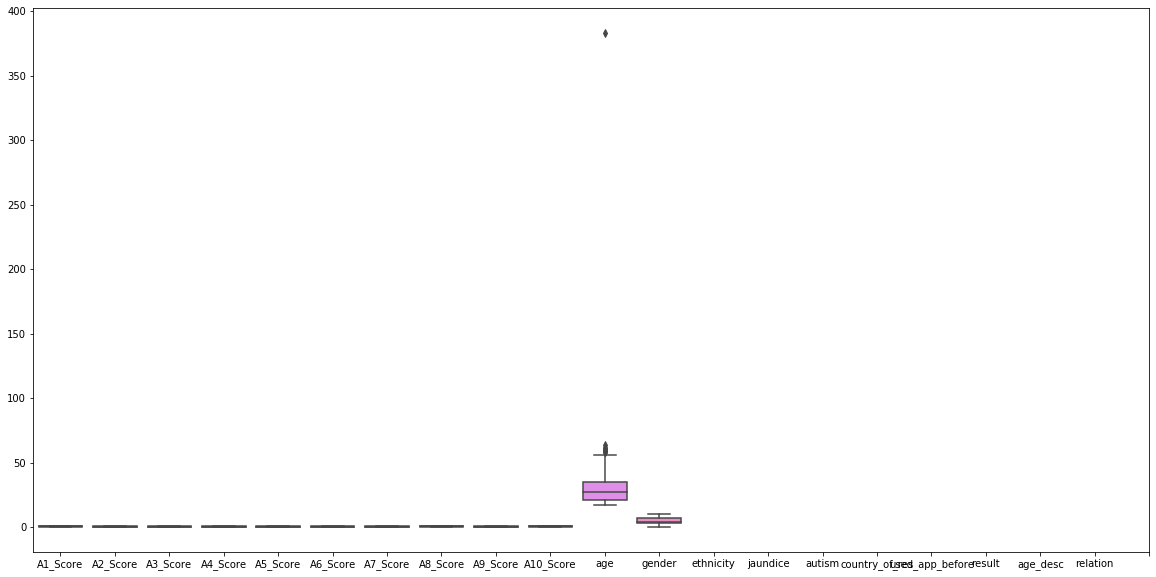

In [82]:
plt.figure(figsize=(20,10))
sns.boxplot(data=X)
plt.xticks(ticks=np.arange(len(data.columns)),labels=X.columns)
plt.show()



In [83]:
# Find and handle the outiers
print("shape :",data.shape)
#data.drop(data[data['age'] == '383'].index, inplace=True)
#remove outliers
print("column type : ",data.age.dtype)
data["age"] = pd.to_numeric(data["age"])

print("column type22 : ",data.age.dtype)

q1=data['age'].quantile(.25)
q3=data['age'].quantile(.75)
IQR = q3 -q1
data['age'] = np.clip(data['age'],q1 - 1.5 * IQR, q3 + 1.5 *IQR)
print("shape after :",data.shape)
print(data['age'].unique())


shape : (704, 21)
column type :  object
column type22 :  int64
shape after : (704, 21)
[26 24 27 35 40 36 56 29 17 33 18 31 43 37 55 34 53 20 30 21 47 28 32 44
 19 45 42 22 39 25 38 23 54 50 41 46 52 48 51 49]


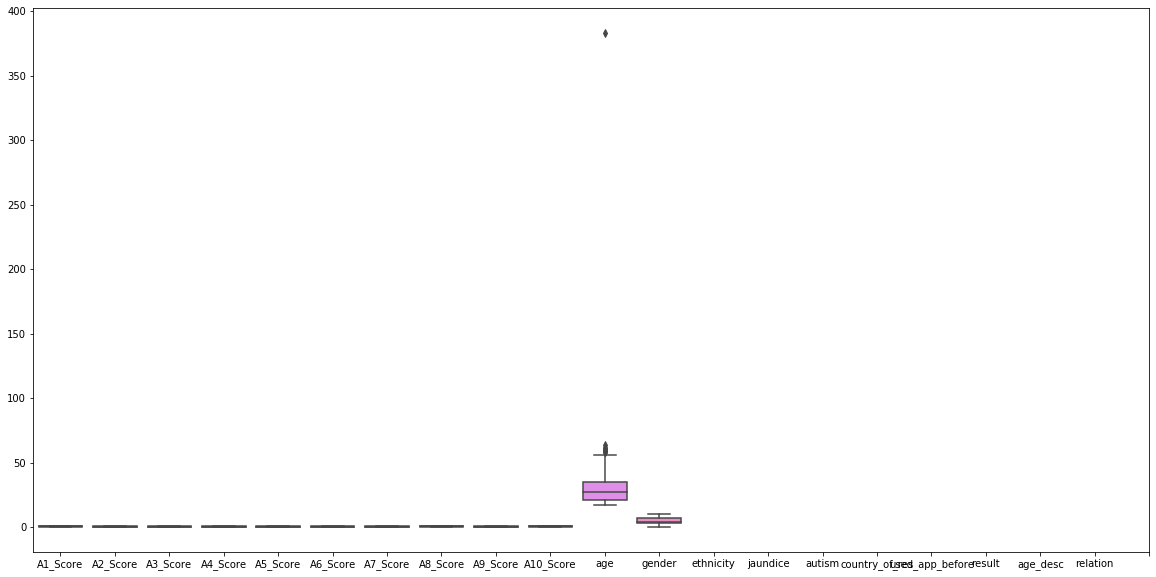

In [84]:
plt.figure(figsize=(20,10))
sns.boxplot(data=X)
plt.xticks(ticks=np.arange(len(data.columns)),labels=X.columns)
plt.show()

In [85]:
most_frequent_relation=data['relation'].mode()[0]
print('most_frequent_relation >> ',most_frequent_relation )
data.loc[(data.relation == '?'), 'relation'] = most_frequent_relation
data['relation'].unique()


most_frequent_relation >>  Self


array(['Self', 'Parent', "'Health care professional'", 'Relative',
       'Others'], dtype=object)

In [86]:
data['ethnicity'].unique()


array(['White-European', 'Latino', 'Others', 'Asian', "'Middle Eastern '",
       'Pasifika', 'Black', "'South Asian'", 'Hispanic', 'Turkish',
       'others'], dtype=object)

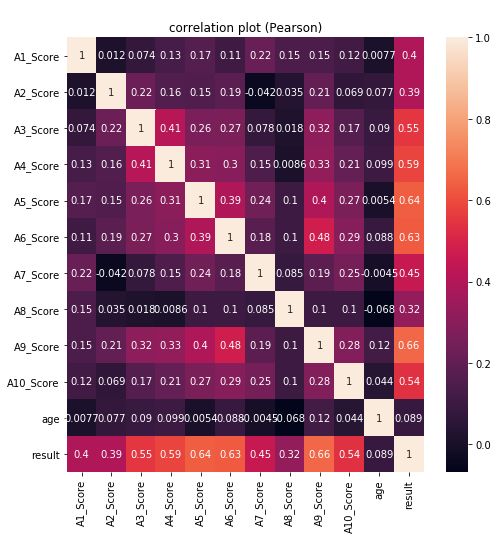

In [87]:
#feature selection
#find correlation in the dataset
plt.figure(figsize = (8,8))
plt.title('\ncorrelation plot (Pearson)')
corr = data.corr()
sns.heatmap(corr,xticklabels=corr.columns,yticklabels=corr.columns,annot=True)

plt.show()


In [88]:
# Removing age_desc variable as it has no relevnce for logistic regression model
data.drop(['age_desc'],axis=1, inplace=True)

In [89]:
#treatment of categorical column

autism_dummies=pd.get_dummies(data,columns=data.columns[:-1])


In [90]:
print("Default of autism_dummies train data -  rows:",autism_dummies.shape[0]," columns:", autism_dummies.shape[1])

Default of autism_dummies train data -  rows: 704  columns: 163


In [91]:
#Assigning and dividing the dataset
print('columns >> ',autism_dummies.columns)
X = autism_dummies.drop('Class_ASD',axis=1)
y=autism_dummies['Class_ASD']

columns >>  Index(['Class_ASD', 'A1_Score_0', 'A1_Score_1', 'A2_Score_0', 'A2_Score_1',
       'A3_Score_0', 'A3_Score_1', 'A4_Score_0', 'A4_Score_1', 'A5_Score_0',
       ...
       'result_6', 'result_7', 'result_8', 'result_9', 'result_10',
       'relation_'Health care professional'', 'relation_Others',
       'relation_Parent', 'relation_Relative', 'relation_Self'],
      dtype='object', length=163)


In [92]:
# Data scaling
from sklearn import preprocessing
standard_scaler = preprocessing.StandardScaler()
X = standard_scaler.fit_transform(X)


In [ ]:
# Data normalization
X = preprocessing.normalize(X)


In [93]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection  import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 5)
X_train.shape

(563, 162)

In [94]:
X_test.shape

(141, 162)

In [95]:
#lable encode target variable
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
y_test=lb.fit_transform(y_test)
y_train=lb.fit_transform(y_train)


In [96]:
#Perform k-fold  cross validation
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import cross_val_score,KFold
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

models=[]
models.append(('lr',LogisticRegression()))
models.append(('decision tree',DecisionTreeClassifier()))

for name,model in models:
    kfold=KFold(n_splits=10,random_state=7)
    cross_val_sc=cross_val_score(model,X,y,scoring='accuracy',cv=kfold)
    print('{} : acc: {}(standard deviation: {})'.format(name,cross_val_sc.mean(),cross_val_sc.std()))

lr : acc: 0.9829577464788732(standard deviation: 0.01397718524840208)
decision tree : acc: 0.9814889336016097(standard deviation: 0.015694680897468918)


In [97]:
#apply logistic regression
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(C=0.4,max_iter=1000,solver='liblinear')
classifier.fit(X_train, y_train)

LogisticRegression(C=0.4, max_iter=1000, solver='liblinear')

In [98]:
#### Predicting on X_test dataset
y_pred = classifier.predict(X_test)
print("y_pred >> ",y_pred)

y_pred >>  [0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 1 1 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0 0 0]


In [99]:
#Performance score of classification model
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[106   0]
 [  3  32]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       106
           1       1.00      0.91      0.96        35

    accuracy                           0.98       141
   macro avg       0.99      0.96      0.97       141
weighted avg       0.98      0.98      0.98       141



In [100]:
#Performance score of classification model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

results = pd.DataFrame([['Logistic Regression', acc, prec, rec, f1]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.978723        1.0  0.914286  0.955224


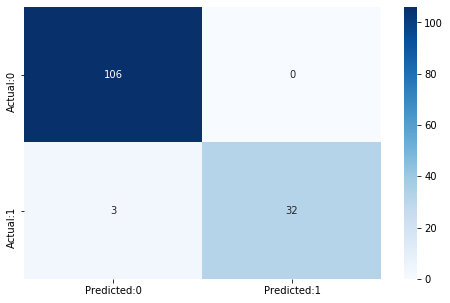

In [101]:
#Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
conf_matrix=pd.DataFrame(data=cm,columns=['Predicted:0','Predicted:1'],index=['Actual:0','Actual:1'])
plt.figure(figsize=(8,5))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues')

In [102]:
TN=cm[0,0]
TP=cm[1,1]
FN=cm[1,0]
FP=cm[0,1]
sensitivity=TP/float(TP+FN)
specificity=TN/float(TN+FP)
print("True Negative",TN)
print("True Positive",TP)
print("False Negative",FN)
print("False Positive",FP)
print("Sensitivity",sensitivity)
print("Specificity",specificity)

True Negative 106
True Positive 32
False Negative 3
False Positive 0
Sensitivity 0.9142857142857143
Specificity 1.0


In [103]:
print('The accuracy of the model = TP+TN/(TP+TN+FP+FN)=',(TP+TN)/float(TP+TN+FP+FN),'\n\n', 
'Misclassification = 1-Accuracy = ', 1-((TP+TN)/float(TP+TN+FP+FN)),'\n\n',
'Sensitivity or True Positive Rate = TP/(TP+FN) = ',TP/float(TP+FN),'\n\n',
'Specificity or True Negative Rate = TN/(TN+FP) = ',TN/float(TN+FP),'\n\n',
'Positive Predictive value = TP/(TP+FP) = ',TP/float(TP+FP),'\n\n',
'Negative Predictive value = TN/(TN+FN) = ',TN/float(TN+FN),'\n\n',
'Positive Likelihood Ratio = Sensitiviity/(1-Specificity) = ',sensitivity/(1-specificity),'\n\n',
'Negative Likelihood Ratio = (1-Sensitivity/Specificity = ',(1 - sensitivity)/specificity)

The accuracy of the model = TP+TN/(TP+TN+FP+FN)= 0.9787234042553191 

 Misclassification = 1-Accuracy =  0.021276595744680882 

 Sensitivity or True Positive Rate = TP/(TP+FN) =  0.9142857142857143 

 Specificity or True Negative Rate = TN/(TN+FP) =  1.0 

 Positive Predictive value = TP/(TP+FP) =  1.0 

 Negative Predictive value = TN/(TN+FN) =  0.9724770642201835 

 Positive Likelihood Ratio = Sensitiviity/(1-Specificity) =  inf 

 Negative Likelihood Ratio = (1-Sensitivity/Specificity =  0.08571428571428574


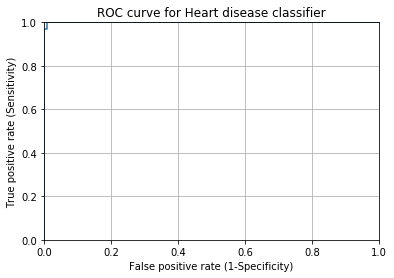

In [104]:

#roc
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test,classifier.predict_proba(X_test)[:,1])
plt.plot(fpr,tpr)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.title('ROC curve for Heart disease classifier')
plt.xlabel('False positive rate (1-Specificity)')
plt.ylabel('True positive rate (Sensitivity)')
plt.grid(True)

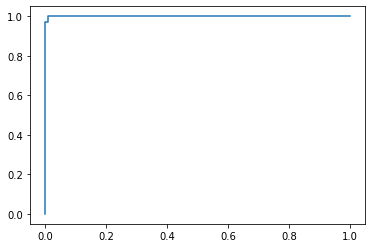

In [107]:
from sklearn import metrics

plt.figure()
#For logistic regression
logit_roc_auc = metrics.roc_auc_score(y_test, classifier.predict(X_test))
lfpr, ltpr, lthresholds = metrics.roc_curve(y_test, classifier.predict_proba(X_test)[:,1])
plt.plot(lfpr, ltpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)


In [93]:
#Area under the curve
from sklearn.metrics import roc_auc_score
print('The area under the curve is : ',round(roc_auc_score(y_test,classifier.predict_proba(X_test)[:,1])*100,2))

The area under the curve is :  100.0
